**Step 1 - Get Libraries and CSV File**

In [42]:
# Add Librarys
install.packages('corrplot')

library(tidyverse)
library(lubridate)
library(broom)
library(scales)
library(knitr)
library(corrplot)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [43]:
# Read CSV File From Github
raw_data <- read.csv('https://raw.githubusercontent.com/bcroman/21006366_DA_Assessment/refs/heads/main/views/Crime_Weather_2014_2016.csv')

In [44]:
# Display CSV Data
summary(raw_data)
glimpse(raw_data)

      year          month       crime_month        major_category    
 Min.   :2014   Min.   : 1.00   Length:252         Length:252        
 1st Qu.:2014   1st Qu.: 3.75   Class :character   Class :character  
 Median :2015   Median : 6.50   Mode  :character   Mode  :character  
 Mean   :2015   Mean   : 6.50                                        
 3rd Qu.:2016   3rd Qu.: 9.25                                        
 Max.   :2016   Max.   :12.00                                        
  total_crimes      avg_temp        avg_dewp        avg_slp     
 Min.   :  925   Min.   :40.81   Min.   :35.19   Min.   : 9690  
 1st Qu.: 1889   1st Qu.:45.21   1st Qu.:39.36   1st Qu.:10000  
 Median : 5187   Median :52.89   Median :46.56   Median :10000  
 Mean   : 8444   Mean   :53.50   Mean   :45.49   Mean   : 9983  
 3rd Qu.:16409   3rd Qu.:61.65   3rd Qu.:51.52   3rd Qu.:10000  
 Max.   :26303   Max.   :67.73   Max.   :55.60   Max.   :10000  
   avg_visib          avg_wdsp        avg_mxpsd        

Rows: 252
Columns: 17
$ year           <int> 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2…
$ month          <int> 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3…
$ crime_month    <chr> "01/01/2014", "01/01/2014", "01/01/2014", "01/01/2014",…
$ major_category <chr> "Robbery", "Violence Against the Person", "Criminal Dam…
$ total_crimes   <int> 2165, 12741, 4464, 4020, 930, 23285, 7910, 1878, 6767, …
$ avg_temp       <dbl> 44.59355, 44.59355, 44.59355, 44.59355, 44.59355, 44.59…
$ avg_dewp       <dbl> 40.44839, 40.44839, 40.44839, 40.44839, 40.44839, 40.44…
$ avg_slp        <dbl> 9999.9, 9999.9, 9999.9, 9999.9, 9999.9, 9999.9, 9999.9,…
$ avg_visib      <dbl> 5.974194, 5.974194, 5.974194, 5.974194, 5.974194, 5.974…
$ avg_wdsp       <dbl> 9.367742, 9.367742, 9.367742, 9.367742, 9.367742, 9.367…
$ avg_mxpsd      <dbl> 16.23226, 16.23226, 16.23226, 16.23226, 16.23226, 16.23…
$ avg_gust       <dbl> 466.0968, 466.0968, 466.0968, 466.0968, 466.0968, 466.0…
$ avg_max_temp   <

Check For Duplicated Values

In [45]:
# Look For Duplicated Rows of Years and Months
raw_data %>% count(year, month) %>% arrange(year, month)

year,month,n
<int>,<int>,<int>
2014,1,7
2014,2,7
2014,3,7
2014,4,7
2014,5,7
2014,6,7
2014,7,7
2014,8,7
2014,9,7


In [46]:
# Shows the List of Unquie Value of Major Category
raw_data %>% distinct(major_category) %>% arrange(major_category)

major_category
<chr>
Burglary
Criminal Damage
Drugs
Other Notifiable Offences
Robbery
Theft and Handling
Violence Against the Person


**Step 2 - Setup Data For Analytics**

In [47]:
# Check Data Values and Replace Default or Place
core_data <- raw_data %>%
  mutate(
    across(c(avg_slp, avg_sndp), ~na_if(., 9999.9)),
    avg_sndp = na_if(avg_sndp, 999.9),
    crime_month = dmy(crime_month)
  )

# Display Cleaned Data
summary(select(core_data, total_crimes, starts_with("avg_"), fog_days))

  total_crimes      avg_temp        avg_dewp        avg_slp    
 Min.   :  925   Min.   :40.81   Min.   :35.19   Min.   :9690  
 1st Qu.: 1889   1st Qu.:45.21   1st Qu.:39.36   1st Qu.:9690  
 Median : 5187   Median :52.89   Median :46.56   Median :9700  
 Mean   : 8444   Mean   :53.50   Mean   :45.49   Mean   :9700  
 3rd Qu.:16409   3rd Qu.:61.65   3rd Qu.:51.52   3rd Qu.:9710  
 Max.   :26303   Max.   :67.73   Max.   :55.60   Max.   :9710  
                                                 NA's   :238   
   avg_visib          avg_wdsp        avg_mxpsd        avg_gust    
 Min.   :  4.465   Min.   : 5.140   Min.   : 9.10   Min.   :308.5  
 1st Qu.:  5.944   1st Qu.: 6.995   1st Qu.:12.19   1st Qu.:552.1  
 Median :  6.332   Median : 7.742   Median :13.13   Median :636.7  
 Mean   : 19.730   Mean   : 7.988   Mean   :13.58   Mean   :636.2  
 3rd Qu.: 14.549   3rd Qu.: 8.990   3rd Qu.:15.00   3rd Qu.:722.4  
 Max.   :106.073   Max.   :12.246   Max.   :20.12   Max.   :934.4  
            

**Step 3 - Create Testing Datasets**

In [48]:
# Create Dataset for Monthly Values
monthly_totals <- core_data %>%
  group_by(year, month, crime_month) %>%
  summarise(
    total_crime = sum(total_crimes, na.rm = TRUE),
    avg_temp = first(avg_temp),
    avg_dewp = first(avg_dewp),
    avg_visib = first(avg_visib),
    avg_wdsp = first(avg_wdsp),
    avg_max_temp = first(avg_max_temp),
    avg_min_temp = first(avg_min_temp),
    avg_prcp = first(avg_prcp),
    fog_days = first(fog_days),
    .groups = "drop"
  ) %>%
  arrange(crime_month) %>%
  mutate(month_factor = factor(month, levels = 1:12, labels = month.abb))

head(monthly_totals)

year,month,crime_month,total_crime,avg_temp,avg_dewp,avg_visib,avg_wdsp,avg_max_temp,avg_min_temp,avg_prcp,fog_days,month_factor
<int>,<int>,<date>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<fct>
2014,1,2014-01-01,55515,44.59355,40.44839,5.974194,9.367742,50.07419,38.55161,0.18806452,5,Jan
2014,2,2014-02-01,51222,45.41786,38.94643,6.542857,12.246429,51.11071,39.59286,0.14464286,1,Feb
2014,3,2014-03-01,57669,48.12258,39.50000,37.709677,7.651613,57.52258,39.90645,0.04096774,7,Mar
2014,4,2014-04-01,53467,52.87000,43.99333,5.813333,7.263333,61.07333,44.89667,0.07400000,4,Apr
2014,5,2014-05-01,56327,56.64516,46.74839,38.387097,7.832258,64.39032,48.81613,0.11193548,0,May
2014,6,2014-06-01,57039,62.91333,50.29000,106.073333,6.290000,71.98333,53.97000,0.05333333,1,Jun


In [49]:
# Create Dataset For Monthly Category
category_monthly <- core_data %>% arrange(crime_month, major_category)

head(category_monthly)

,year,month,crime_month,major_category,total_crimes,avg_temp,avg_dewp,avg_slp,avg_visib,avg_wdsp,avg_mxpsd,avg_gust,avg_max_temp,avg_min_temp,avg_prcp,avg_sndp,fog_days
,<int>,<int>,<date>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1,2014,1,2014-01-01,Burglary,7910,44.59355,40.44839,NA,5.974194,9.367742,16.23226,466.0968,50.07419,38.55161,0.1880645,NA,5
2,2014,1,2014-01-01,Criminal Damage,4464,44.59355,40.44839,NA,5.974194,9.367742,16.23226,466.0968,50.07419,38.55161,0.1880645,NA,5
3,2014,1,2014-01-01,Drugs,4020,44.59355,40.44839,NA,5.974194,9.367742,16.23226,466.0968,50.07419,38.55161,0.1880645,NA,5
4,2014,1,2014-01-01,Other Notifiable Offences,930,44.59355,40.44839,NA,5.974194,9.367742,16.23226,466.0968,50.07419,38.55161,0.1880645,NA,5
5,2014,1,2014-01-01,Robbery,2165,44.59355,40.44839,NA,5.974194,9.367742,16.23226,466.0968,50.07419,38.55161,0.1880645,NA,5
6,2014,1,2014-01-01,Theft and Handling,23285,44.59355,40.44839,NA,5.974194,9.367742,16.23226,466.0968,50.07419,38.55161,0.1880645,NA,5


**Step 4 - Plotting Data**

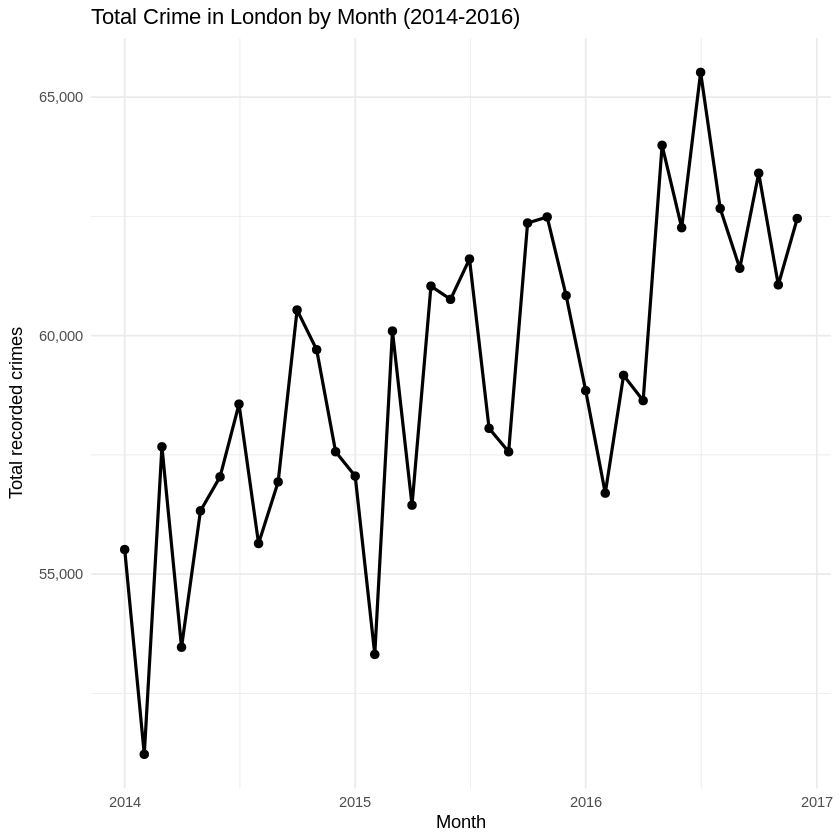

In [50]:
# Create Line Chart to Show Total Crimes in london Through 2014 to 2016
ggplot(monthly_totals, aes(x = crime_month, y = total_crime)) +
  geom_line(linewidth = 0.9) +
  geom_point(size = 2) +
  scale_y_continuous(labels = comma) +
  labs(
    title = "Total Crime in London by Month (2014-2016)",
    x = "Month",
    y = "Total recorded crimes"
  ) + theme_minimal()

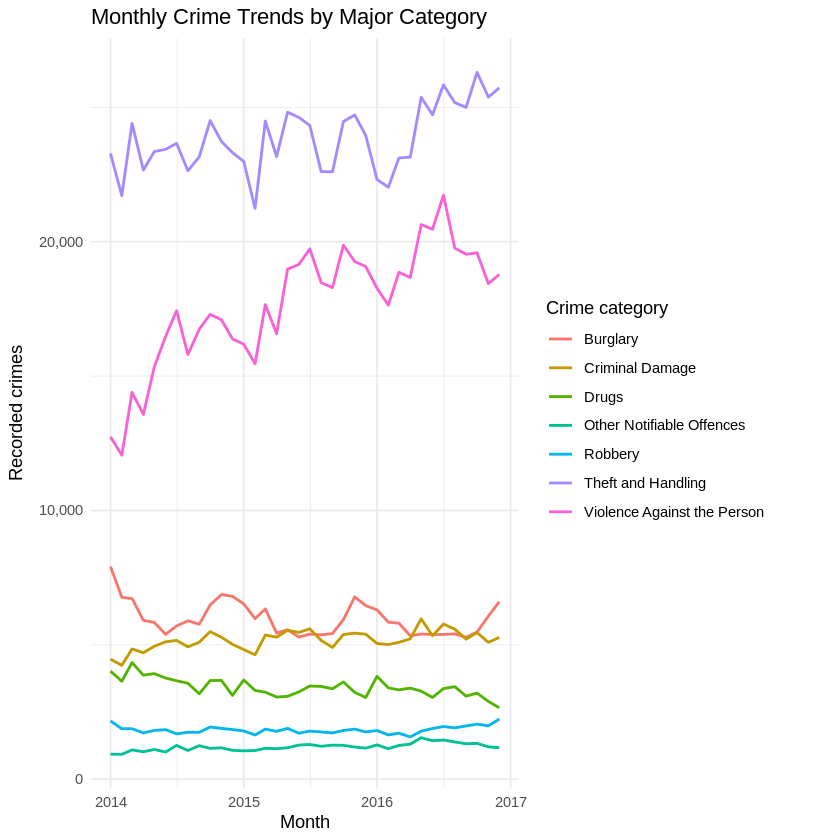

In [51]:
# Line Charts to show total crime categroy over years
category_monthly %>%
  ggplot(aes(x = crime_month, y = total_crimes, color = major_category)) +
  geom_line(linewidth = 0.8) +
  scale_y_continuous(labels = comma) +
  labs(
    title = "Monthly Crime Trends by Major Category",
    x = "Month",
    y = "Recorded crimes",
    color = "Crime category"
  ) +
  theme_minimal()

`geom_smooth()` using formula = 'y ~ x'


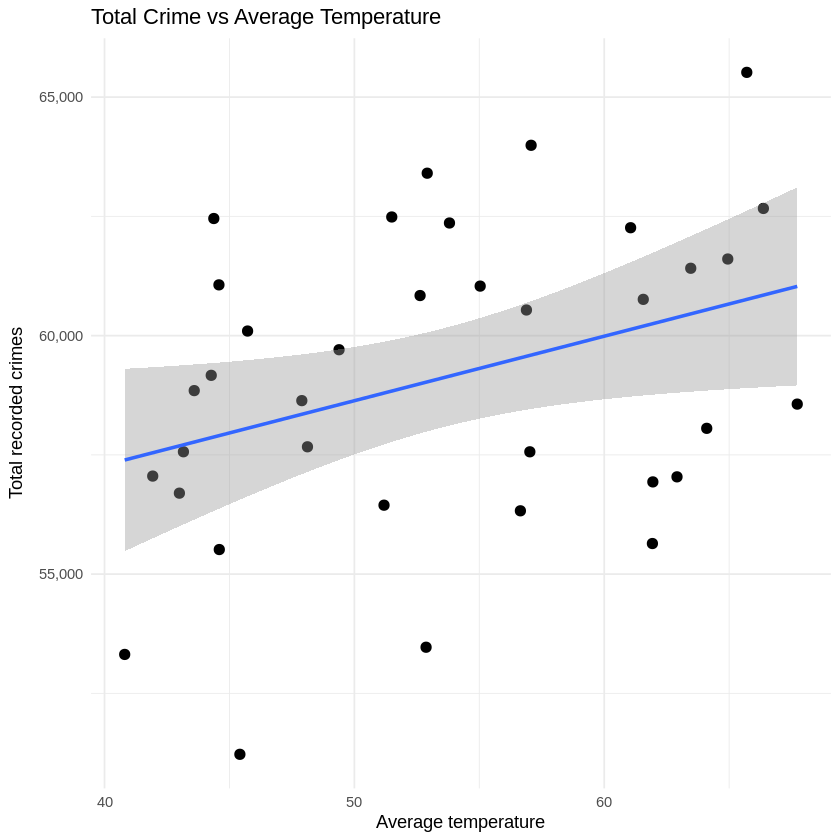

In [52]:
# Line Charts to show total crimes vs average temperature
ggplot(monthly_totals, aes(x = avg_temp, y = total_crime)) +
  geom_point(size = 2.5) +
  geom_smooth(method = "lm", se = TRUE) +
  scale_y_continuous(labels = comma) +
  labs(
    title = "Total Crime vs Average Temperature",
    x = "Average temperature",
    y = "Total recorded crimes"
  ) +
  theme_minimal()

`geom_smooth()` using formula = 'y ~ x'


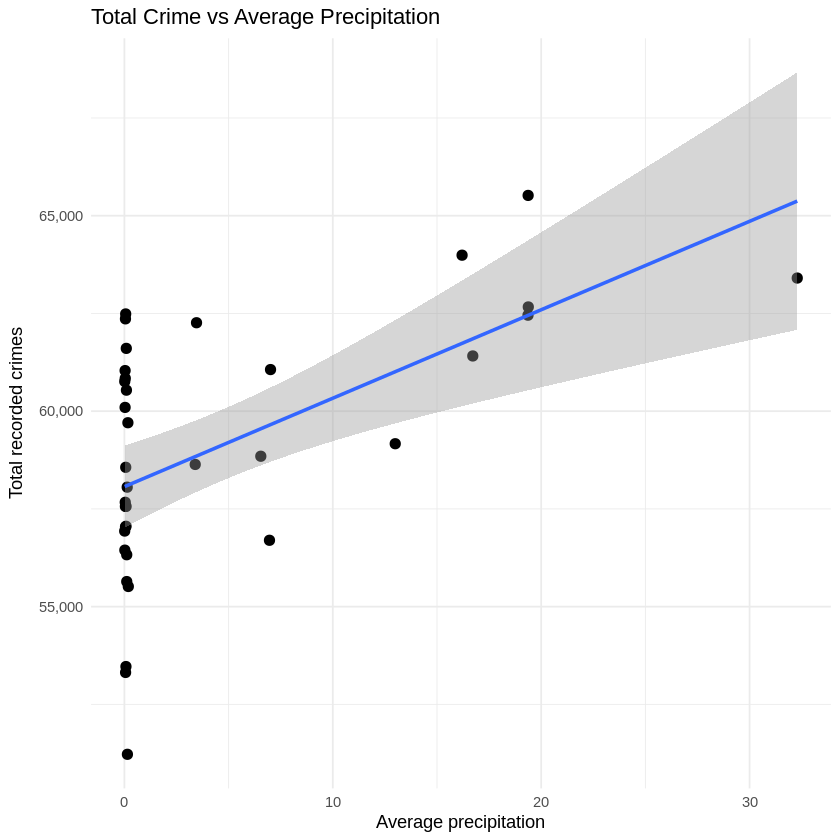

In [53]:
# Line Charts to show total crime vs average rainfall
ggplot(monthly_totals, aes(x = avg_prcp, y = total_crime)) +
  geom_point(size = 2.5) +
  geom_smooth(method = "lm", se = TRUE) +
  scale_y_continuous(labels = comma) +
  labs(
    title = "Total Crime vs Average Precipitation",
    x = "Average precipitation",
    y = "Total recorded crimes"
  ) +
  theme_minimal()

**Step 5 - Correlation Matrix**

In [54]:
# Overall Correlation Matrix for Monthly Totals
correlation_table <- monthly_totals %>%
  select(total_crime, avg_temp, avg_dewp, avg_visib, avg_wdsp, avg_max_temp,
         avg_min_temp, avg_prcp, fog_days) %>%
  cor(use = "complete.obs") %>% round(5)

correlation_table

,total_crime,avg_temp,avg_dewp,avg_visib,avg_wdsp,avg_max_temp,avg_min_temp,avg_prcp,fog_days
total_crime,1.00000,0.34901,0.41256,-0.13848,-0.20119,0.31262,0.37813,0.56791,0.11998
avg_temp,0.34901,1.00000,0.94232,0.33638,-0.30320,0.99167,0.99194,0.08543,-0.37587
avg_dewp,0.41256,0.94232,1.00000,0.14328,-0.34047,0.90171,0.96743,0.13884,-0.21440
avg_visib,-0.13848,0.33638,0.14328,1.00000,-0.14861,0.39649,0.27617,-0.28631,-0.25187
avg_wdsp,-0.20119,-0.30320,-0.34047,-0.14861,1.00000,-0.33380,-0.27803,-0.27338,-0.36945
avg_max_temp,0.31262,0.99167,0.90171,0.39649,-0.33380,1.00000,0.96917,0.07102,-0.37640
avg_min_temp,0.37813,0.99194,0.96743,0.27617,-0.27803,0.96917,1.00000,0.09676,-0.35741
avg_prcp,0.56791,0.08543,0.13884,-0.28631,-0.27338,0.07102,0.09676,1.00000,0.43365
fog_days,0.11998,-0.37587,-0.21440,-0.25187,-0.36945,-0.37640,-0.35741,0.43365,1.00000


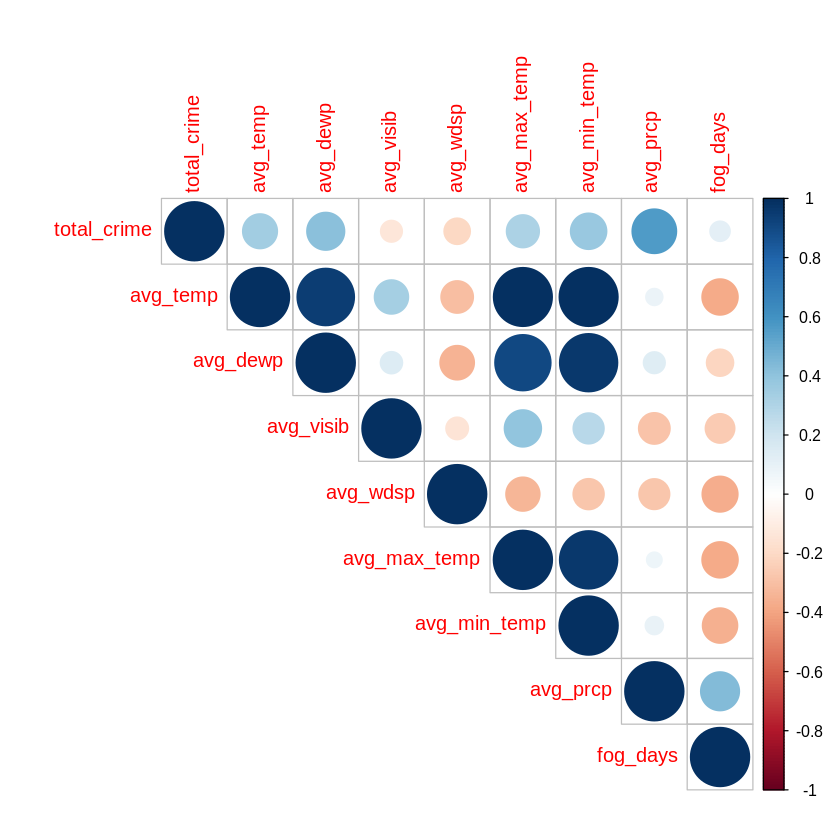

In [55]:
# Overall Correlation Matrix Chart
corrplot(correlation_table, type = 'upper')

In [56]:
# Weather Vs Crime Matrix Values
cor(monthly_totals$total_crime, monthly_totals$avg_temp, method = 'pearson')
cor(monthly_totals$total_crime, monthly_totals$avg_prcp, method = 'pearson')

[1] 0.3490138

[1] 0.5679142